# E-commerce Analytics: Когортный и RFM-анализ маркетплейса Olist
### Описание проекта
**Olist** – крупнейший бразильский маркетплейс (платформа-интегратор для интернет-магазинов). В данном проекте исследуются данные о заказах за 2017-2018 годы.

**Цель исследования:** Оценить текущее состояние клиентской базы, выявить паттерны покупательского поведения, рассчитать метрики удержания и сегментировать аудиторию для оптимизации маркетинговых затрат.

---

### Ключевые гипотезы

* **H1**: Если бизнес-модель Olist ориентирована на non-FMCG товары с низкой частотой повторных покупок, то Retention Rate первого месяца (`Cohort Index` = 1) не превысит 1.5% ни в одной когорте.
  
  **Метрика проверки:** Метрика удержания (Retention Rate) по матрице когортного анализа.

* **H2**: Если когорты формируются в период подготовки к сезону распродаж (сентябрь–октябрь), то их Retention Rate на первом месяце жизни будет статистически значимо выше, чем у когорт остальных периодов.

  **Метрика проверки:** Сравнительный анализ Retention Rate (`Cohort Index 1`) для осенних и весенне-летних когорт.

* **H3**: Если часть аудитории совершает покупки под ежегодные сезонные инфоповоды, то на 12-м месяце жизни отдельных когорт будет зафиксирован локальный всплеск Retention Rate, выходящий за пределы доверительного интервала фонового уровня.

  **Метрика проверки:** Анализ экстремумов на шаге `Cohort Index 12` матрицы удержания.

* **H4**: Если сегментировать клиентскую базу по RFM-метрикам, то узкая группа высокочековых клиентов будет генерировать непропорционально большую долю выручки относительно своей доли в базе.

  **Метрика проверки:** Доля клиентов в % против доли выручки в % в матрице RFM-сегментации.
---
### Стек
Python (Pandas, NumPy, Matplotlib, Seaborn, Statsmodels) Когортный анализ (Retention Rate), RFM-сегментация.

---

## Содержание
1. Импорт библиотек и настройка
2. Загрузка данных
3. EDA (Разведочный анализ данных)
4. Когортный анализ и расчет Retention Rate
5. RFM-сегментация клиентов
6. Стратегическое резюме

---

## 1. Импорт библиотек и настройка

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportion_confint

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 2. Загрузка данных

In [ ]:
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')

payments_sum = payments.groupby('order_id')['payment_value'].sum().reset_index()

step1 = orders[orders['order_status'] == 'delivered'].copy()
step1['order_purchase_timestamp'] = pd.to_datetime(step1['order_purchase_timestamp'])
print(f"После фильтра 'delivered':     {len(step1):,} заказов")

step2 = step1.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='inner')
lost_customers = len(step1) - len(step2)
print(f"После мержа с customers:       {len(step2):,} заказов  (потеряно: {lost_customers})")

step3 = step2.merge(payments_sum, on='order_id', how='inner')
lost_payments = len(step2) - len(step3)
print(f"После мержа с payments:        {len(step3):,} заказов  (потеряно: {lost_payments})")

# Границы датасета Olist: данные начинаются с января 2017.
# Верхняя граница – август 2018: последний полный месяц в датасете.
# Сентябрь 2018 содержит единичные записи (артефакт выгрузки), исключаем.
DATE_START = '2017-01-01'
DATE_END   = '2018-08-31'

print(f"Диапазон дат в исходных данных: "
      f"{step3['order_purchase_timestamp'].min().date()} – "
      f"{step3['order_purchase_timestamp'].max().date()}")

step4 = step3[
    (step3['order_purchase_timestamp'] >= DATE_START) &
    (step3['order_purchase_timestamp'] <= DATE_END)
]
lost_dates = len(step3) - len(step4)
print(f"После фильтра по датам:        {len(step4):,} заказов  (потеряно: {lost_dates})")
print(f"Период анализа: {DATE_START} – {DATE_END}")

# Исследуем нулевые платежи
zero_payments = step4[step4['payment_value'] == 0]
print(f"Заказы с payment_value == 0: {len(zero_payments)}")

if len(zero_payments) > 0:
    zero_payment_types = payments[payments['order_id'].isin(zero_payments['order_id'])]
    print("\nТипы оплаты у нулевых заказов:")
    print(zero_payment_types['payment_type'].value_counts())
    print("\nПример заказов:")
    print(zero_payments[['order_id', 'order_status']].head())

step5 = step4[step4['payment_value'] > 0]
lost_zero = len(step4) - len(step5)
print(f"\nПосле фильтра payment_value>0: {len(step5):,} заказов  (потеряно: {lost_zero})")
print("Решение: нулевые платежи исключены, так как не несут монетарной ценности для RFM-анализа.")

marketing_df = step5[['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'payment_value']].copy()
dupes = marketing_df['order_id'].duplicated().sum()
print(f"Дублей order_id: {dupes}")
print(f"\nИтоговый датафрейм: {len(marketing_df):,} строк, "
      f"{marketing_df['customer_unique_id'].nunique():,} уникальных клиентов")
print("Проверка пройдена: нулевых платежей в датасете нет.")

После фильтра 'delivered':     96,478 заказов
После мержа с customers:       96,478 заказов  (потеряно: 0)
После мержа с payments:        96,477 заказов  (потеряно: 1)
Диапазон дат в исходных данных: 2016-10-03 – 2018-08-29
После фильтра по датам:        96,211 заказов  (потеряно: 266)
Период анализа: 2017-01-01 – 2018-08-31
Заказы с payment_value == 0: 0

После фильтра payment_value>0: 96,211 заказов  (потеряно: 0)
Решение: нулевые платежи исключены, так как не несут монетарной ценности для RFM-анализа.
Дублей order_id: 0

Итоговый датафрейм: 96,211 строк, 93,104 уникальных клиентов
Проверка пройдена: нулевых платежей в датасете нет.


## 3. EDA (Разведочный анализ данных)

In [ ]:
orders_per_customer = marketing_df.groupby('customer_unique_id')['order_id'].count()

median_val = marketing_df['payment_value'].median()
mean_val   = marketing_df['payment_value'].mean()
p95        = marketing_df['payment_value'].quantile(0.95)

repeat_customers = (orders_per_customer > 1).sum()
repeat_pct       = repeat_customers / len(orders_per_customer) * 100

print(f"Уникальных клиентов:        {marketing_df['customer_unique_id'].nunique():,}")
print(f"Уникальных заказов:         {marketing_df['order_id'].nunique():,}")
print(f"Средний чек:                {mean_val:.2f} BRL")
print(f"Медианный чек:              {median_val:.2f} BRL")
print(f"Среднее заказов на клиента: {orders_per_customer.mean():.3f}")
print(f"\nПовторные покупатели (больше 2):  {repeat_customers:,} ({repeat_pct:.1f}%)")
print(f"Одноразовые покупатели:     {len(orders_per_customer) - repeat_customers:,} ({100 - repeat_pct:.1f}%)")


Уникальных клиентов:        93,104
Уникальных заказов:         96,211
Средний чек:                159.81 BRL
Медианный чек:              105.28 BRL
Среднее заказов на клиента: 1.033

Повторные покупатели (больше 2):  2,789 (3.0%)
Одноразовые покупатели:     90,315 (97.0%)


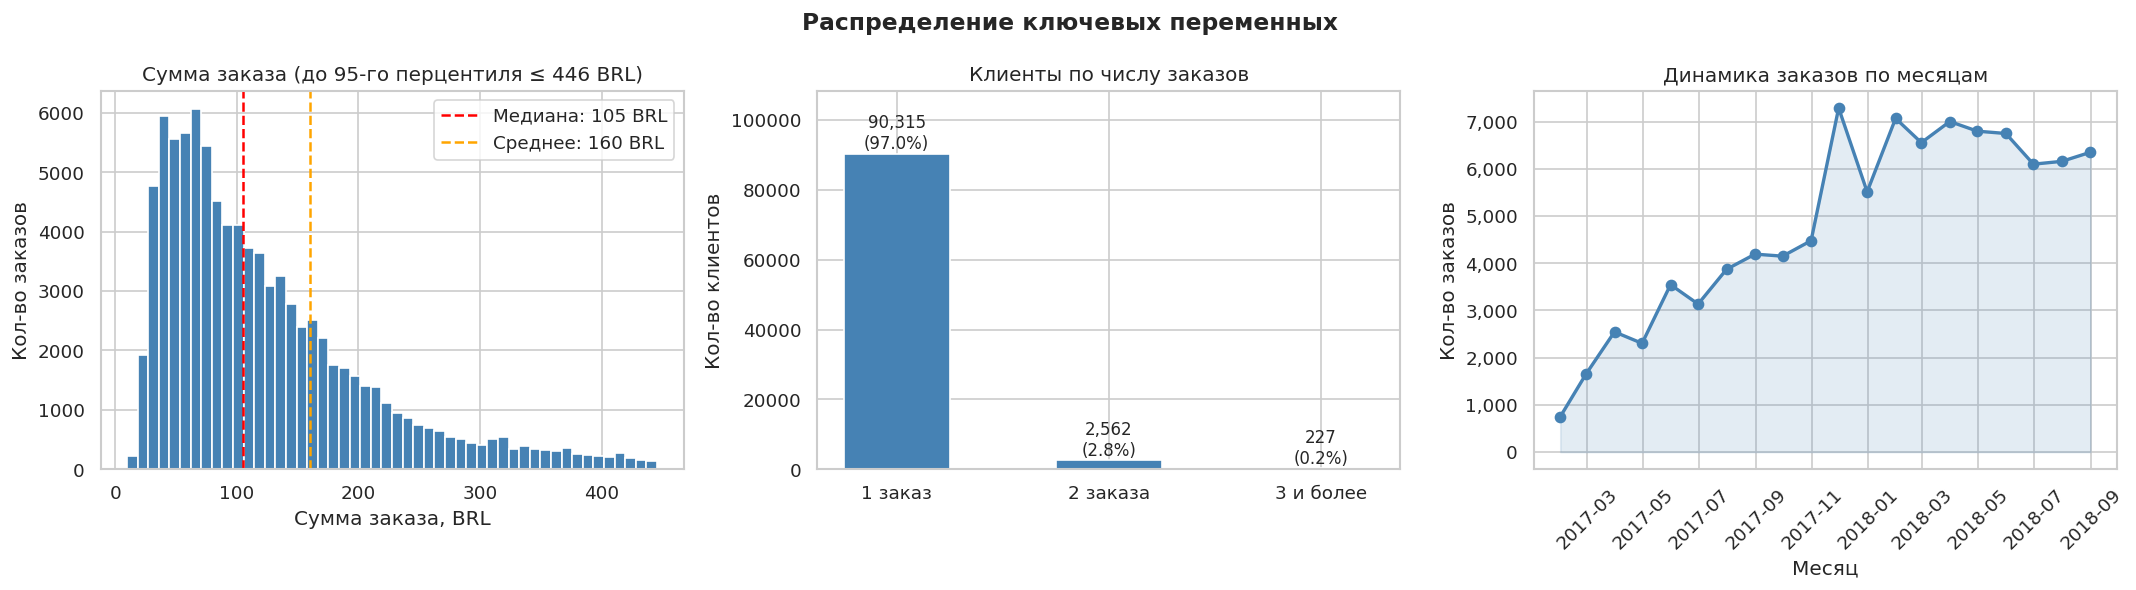

In [ ]:
# Визуализация EDA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Распределение ключевых переменных', fontsize=14, fontweight='bold')

# График 1: Сумма заказа
data_trimmed = marketing_df[marketing_df['payment_value'] <= p95]['payment_value']

axes[0].hist(data_trimmed, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(median_val, color='red',    linestyle='--', linewidth=1.5,
                label=f'Медиана: {median_val:.0f} BRL')
axes[0].axvline(mean_val,   color='orange', linestyle='--', linewidth=1.5,
                label=f'Среднее: {mean_val:.0f} BRL')
axes[0].set_title(f'Сумма заказа (до 95-го перцентиля ≤ {p95:.0f} BRL)')
axes[0].set_xlabel('Сумма заказа, BRL')
axes[0].set_ylabel('Кол-во заказов')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend()

# График 2: Число заказов на клиента
freq_grouped = orders_per_customer.copy()
freq_grouped[freq_grouped >= 3] = 3
freq_counts = freq_grouped.value_counts().sort_index()
x_labels = {1: '1 заказ', 2: '2 заказа', 3: '3 и более'}
total = freq_counts.sum()

bars = axes[1].bar(
    [x_labels[i] for i in freq_counts.index],
    freq_counts.values,
    color='steelblue', edgecolor='white', width=0.5
)
axes[1].set_title('Клиенты по числу заказов')
axes[1].set_ylabel('Кол-во клиентов')
axes[1].set_ylim(0, freq_counts.max() * 1.2)
for bar, val in zip(bars, freq_counts.values):
    pct = val / total * 100
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f'{val:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )

# График 3: Динамика заказов по месяцам
monthly = (
    marketing_df
    .set_index('order_purchase_timestamp')
    .resample('ME')['order_id']
    .count()
)
axes[2].plot(monthly.index, monthly.values, marker='o', color='steelblue', linewidth=2)
axes[2].fill_between(monthly.index, monthly.values, alpha=0.15, color='steelblue')
axes[2].set_title('Динамика заказов по месяцам')
axes[2].set_xlabel('Месяц')
axes[2].set_ylabel('Кол-во заказов')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()


## Выводы EDA

Среднее значение чека (160 BRL) превышает медиану (105 BRL) на 55 BRL –
распределение имеет тяжёлый правый хвост. Небольшая группа крупных заказов
смещает среднее вверх, что уже на этом этапе указывает на неравномерность
выручки.

97% клиентов совершили ровно одну покупку. Среднее число заказов на клиента –
1.03. Фактически LTV большинства клиентов равен первому чеку.

Динамика заказов показывает устойчивый рост с середины 2017 года
и характерный провал в январе 2018 – постпраздничный спад после
ноябрьского пика. Платформа находится в фазе активного роста,
однако этот рост полностью обеспечивается новым трафиком.

## 4. Когортный анализ и расчет Retention Rate

In [ ]:
# Подготовка когортных данных
marketing_df['order_month'] = marketing_df['order_purchase_timestamp'].dt.to_period('M')
marketing_df['cohort_month'] = (
    marketing_df.groupby('customer_unique_id')['order_month'].transform('min')
)

marketing_df['cohort_index'] = (
    (marketing_df['order_month'].dt.year - marketing_df['cohort_month'].dt.year) * 12 +
    (marketing_df['order_month'].dt.month - marketing_df['cohort_month'].dt.month)
)


cohort_counts = (
    .unstack(fill_value=0)
)

cohort_sizes = cohort_counts[0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Размеры когорт
print(cohort_sizes.to_string())


cohort_month
2017-01     718
2017-02    1628
2017-03    2503
2017-04    2257
2017-05    3451
2017-06    3037
2017-07    3753
2017-08    4057
2017-09    4005
2017-10    4328
2017-11    7061
2017-12    5338
2018-01    6843
2018-02    6288
2018-03    6775
2018-04    6582
2018-05    6508
2018-06    5879
2018-07    5949
2018-08    6144
Freq: M


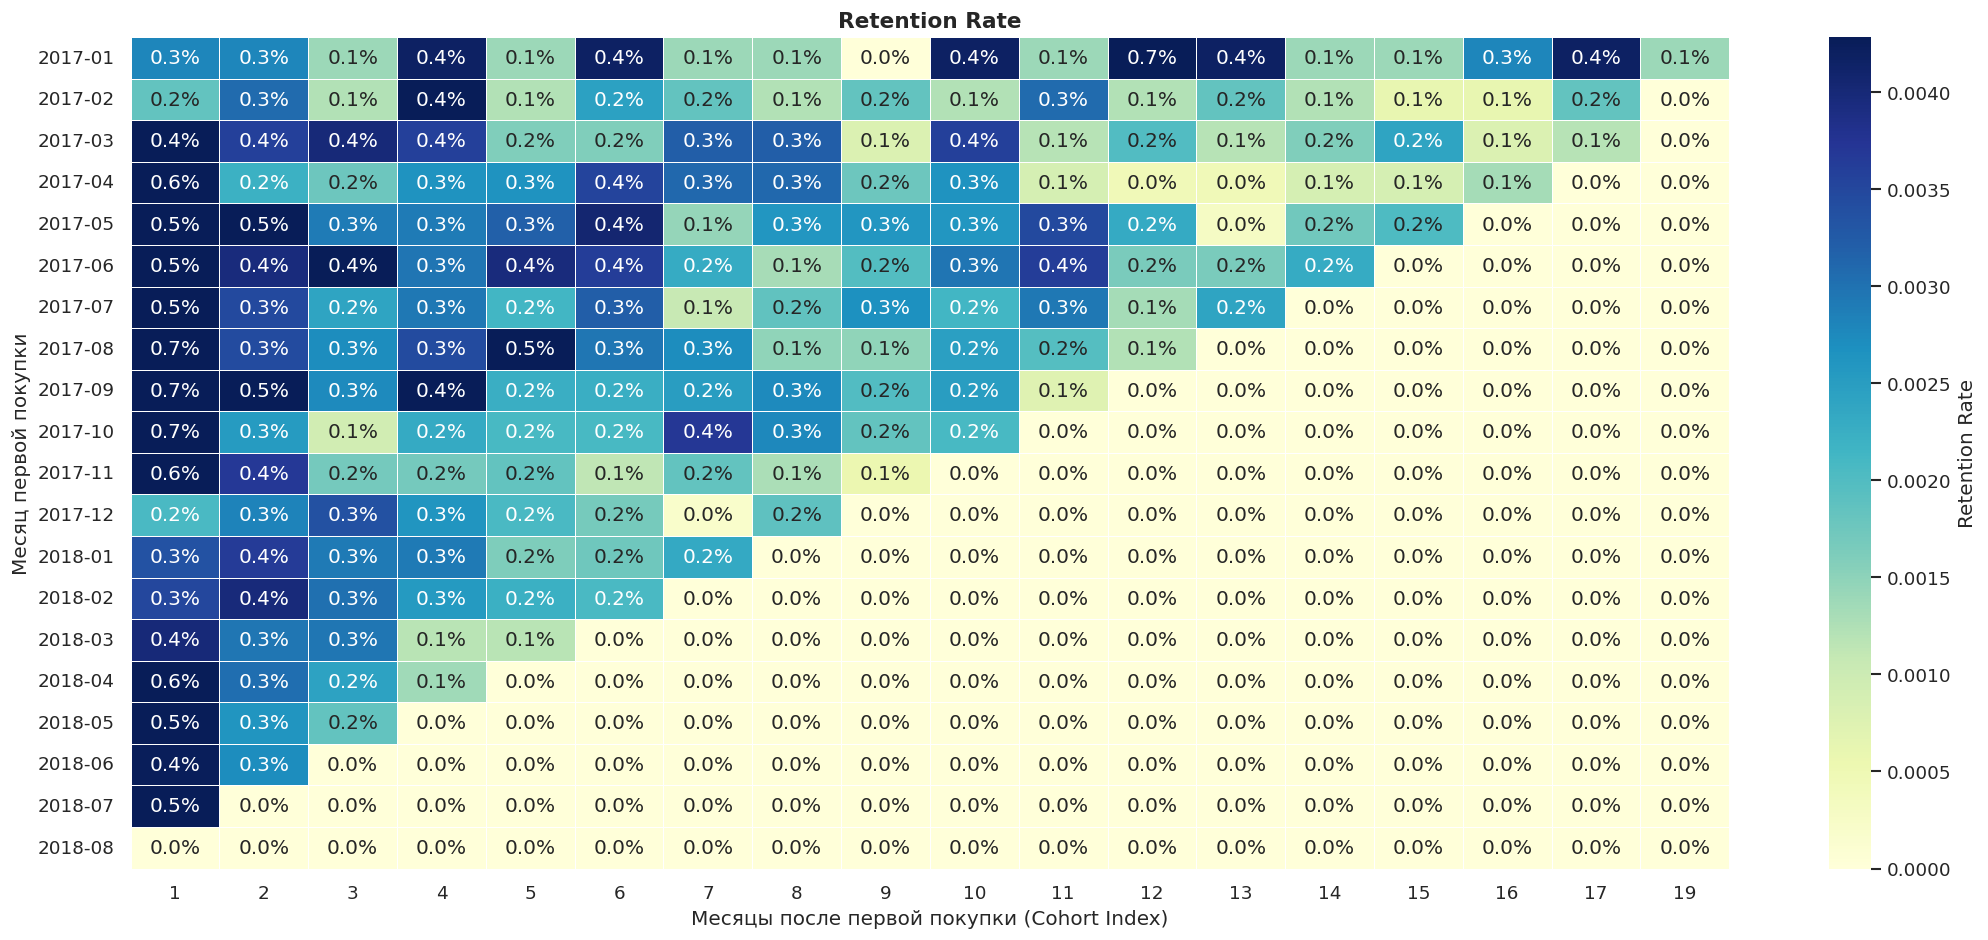

In [ ]:
# Карта 1: Retention Rate
retention_view = retention.drop(columns=[0], errors='ignore')
vmax = retention_view.stack().quantile(0.95)

fig, ax = plt.subplots(figsize=(18, 8))

sns.heatmap(
    retention_view,
    annot=True,
    fmt='.1%',
    cmap='YlGnBu',
    ax=ax,
    linewidths=0.3,
    vmin=0,
    vmax=vmax,
    cbar_kws={'label': 'Retention Rate'},
)
ax.set_title('Retention Rate', fontsize=13, fontweight='bold')
ax.set_xlabel('Месяцы после первой покупки (Cohort Index)')
ax.set_ylabel('Месяц первой покупки')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

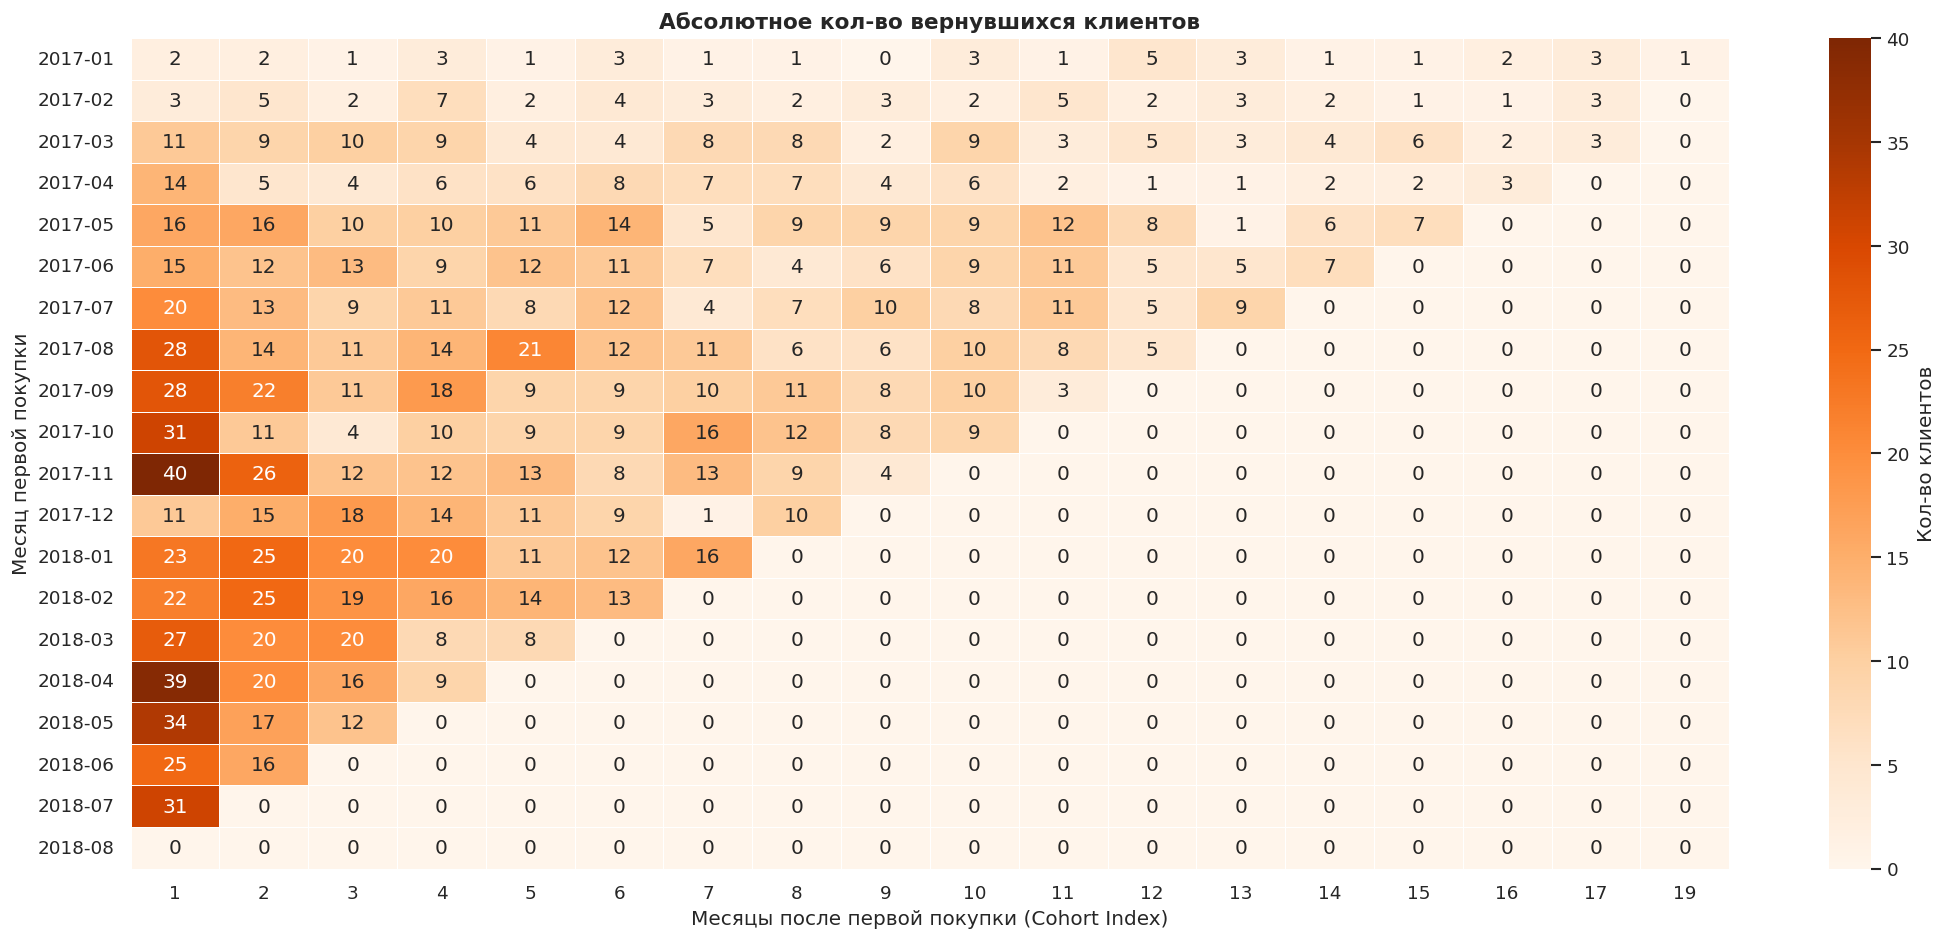

In [ ]:
# Карта 2: Абсолютные числа
counts_view = cohort_counts.drop(columns=[0], errors='ignore')

fig, ax = plt.subplots(figsize=(18, 8))

sns.heatmap(
    counts_view,
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=ax,
    linewidths=0.3,
    cbar_kws={'label': 'Кол-во клиентов'},
)
ax.set_title('Абсолютное кол-во вернувшихся клиентов', fontsize=13, fontweight='bold')
ax.set_xlabel('Месяцы после первой покупки (Cohort Index)')
ax.set_ylabel('Месяц первой покупки')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Проверка гипотезы H1
m1_retention = retention_view[1].dropna()

print(f"""
Retention Rate на 1-м месяце по всем когортам:
  Минимум:  {m1_retention.min():.2%}
  Максимум: {m1_retention.max():.2%}
  Медиана:  {m1_retention.median():.2%}
  Среднее:  {m1_retention.mean():.2%}

H1 ПОДТВЕРЖДЕНА: Retention первого месяца не превышает 1.5% ни в одной когорте. В среднем {(1 - m1_retention.mean()) * 100:.1f}% клиентов не возвращаются на следующий месяц. Бизнес-модель работает в режиме одноразовых продаж.
""")


Retention Rate на 1-м месяце по всем когортам:
  Минимум:  0.00%
  Максимум: 0.72%
  Медиана:  0.48%
  Среднее:  0.45%

H1 ПОДТВЕРЖДЕНА: Retention первого месяца не превышает 1.5% ни в одной когорте. В среднем 99.5% клиентов не возвращаются на следующий месяц. Бизнес-модель работает в режиме одноразовых продаж.



In [ ]:
# Проверка гипотезы H2
m1 = retention_view[1].dropna()
m1.index = m1.index.astype(str)

# Осенние когорты (сентябрь–октябрь) vs остальные
autumn = m1[m1.index.str.contains('-09|-10')]
others = m1[~m1.index.str.contains('-09|-10')]

stat, p_value = stats.mannwhitneyu(autumn, others, alternative='greater')

print(f"""
Осенние когорты (сен–окт):
  n       = {len(autumn)}
  Среднее = {autumn.mean():.3%}
  Медиана = {autumn.median():.3%}

Остальные когорты:
  n       = {len(others)}
  Среднее = {others.mean():.3%}
  Медиана = {others.median():.3%}

Mann-Whitney U = {stat:.1f}, p-value = {p_value:.4f}
""")

if p_value < 0.05:
    conclusion = "ЧАСТИЧНО ПОДТВЕРЖДЕНА"
    interpretation = (
        f"Осенние когорты показывают более высокий retention на первом месяце "
        f"({autumn.mean():.3%} vs {others.mean():.3%}), различие статистически значимо (p={p_value:.4f}).\n\n"
        f"Ограничение: осенняя группа содержит всего {len(autumn)} когорты. "
        f"При n=2 тест Манна-Уитни имеет крайне низкую мощность – результат указывает "
        f"на тенденцию, но не является устойчивым выводом. "
        f"Для подтверждения необходимы данные минимум за 3-4 года.\n\n"
        f"Рекомендация: усиливать перформанс-кампании в августе-сентябре как рабочую гипотезу, "
        f"верифицировать при накоплении данных."
    )
else:
    conclusion = "НЕ ПОДТВЕРЖДЕНА"
    interpretation = f"Статистически значимых различий не обнаружено (p={p_value:.4f})."

print(f"H2 {conclusion}: {interpretation}")


Осенние когорты (сен–окт):
  n       = 2
  Среднее = 0.708%
  Медиана = 0.708%

Остальные когорты:
  n       = 18
  Среднее = 0.423%
  Медиана = 0.452%

Mann-Whitney U = 36.0, p-value = 0.0053

H2 ЧАСТИЧНО ПОДТВЕРЖДЕНА: Осенние когорты показывают более высокий retention на первом месяце (0.708% vs 0.423%), различие статистически значимо (p=0.0053).

Ограничение: осенняя группа содержит всего 2 когорты. При n=2 тест Манна-Уитни имеет крайне низкую мощность – результат указывает на тенденцию, но не является устойчивым выводом. Для подтверждения необходимы данные минимум за 3-4 года.

Рекомендация: усиливать перформанс-кампании в августе-сентябре как рабочую гипотезу, верифицировать при накоплении данных.


In [ ]:
# Проверка гипотезы H3
if 12 in cohort_counts.columns:
    cohort_12    = cohort_counts[12].dropna()
    sizes_12     = cohort_sizes[cohort_12.index]
    retention_12 = (cohort_12 / sizes_12).dropna()

    print(f"{'Когорта':<12} {'Retention':>10} {'n (вернулось)':>15} {'Размер когорты':>16} {'95% CI':>20}")
    print("-" * 75)

    for cohort in retention_12.index:
        n    = int(cohort_12.loc[cohort])
        size = int(sizes_12.loc[cohort])
        ret  = retention_12[cohort]
        ci   = proportion_confint(n, size, alpha=0.05, method='wilson')
        print(f"{str(cohort):<12} {ret:>10.2%} {n:>15} {size:>16} {f'[{ci[0]:.2%}, {ci[1]:.2%}]':>20}")

    peak_cohort  = retention_12.idxmax()
    peak_ret     = retention_12[peak_cohort]
    peak_n       = int(cohort_12.loc[peak_cohort])
    peak_size    = int(sizes_12.loc[peak_cohort])
    peak_ci      = proportion_confint(peak_n, peak_size, alpha=0.05, method='wilson')
    median_ret12 = retention_12.median()

    RELEVANCE_THRESHOLD = 20

    if peak_n >= RELEVANCE_THRESHOLD:
        conclusion    = "ПОДТВЕРЖДЕНА"
        business_note = "Эффект статистически реален и бизнесово значим."
    else:
        conclusion    = "ПОДТВЕРЖДЕНА СТАТИСТИЧЕСКИ, НО БИЗНЕСОВО НЕРЕЛЕВАНТНА"
        business_note = (
            f"За наблюдением стоит n={peak_n} клиентов – эффект реален статистически "
            f"(CI не перекрывается с фоном), но масштаб слишком мал для операционных решений.\n\n"
            f"Интерпретация про сезонные категории товаров – гипотеза, "
            f"не подкреплённая категориальными данными. Для проверки необходим "
            f"анализ order_items + product_category_name для этих {peak_n} клиентов.\n\n"
            f"Рекомендация: зафиксировать паттерн, верифицировать на расширенной выборке "
            f"при накоплении данных за 2-3 года."
        )

    print(f"""
H3 {conclusion}
  Пиковая когорта: {peak_cohort}
  Retention:       {peak_ret:.2%}
  Медиана по шагу: {median_ret12:.2%}
  n:               {peak_n} клиентов из {peak_size}
  95% CI:          [{peak_ci[0]:.2%}, {peak_ci[1]:.2%}]

{business_note}
""")
else:
    print("H3: недостаточно данных – когорт с 12-м месяцем жизни нет.")

Когорта       Retention   n (вернулось)   Размер когорты               95% CI
---------------------------------------------------------------------------
2017-01           0.70%               5              718       [0.30%, 1.62%]
2017-02           0.12%               2             1628       [0.03%, 0.45%]
2017-03           0.20%               5             2503       [0.09%, 0.47%]
2017-04           0.04%               1             2257       [0.01%, 0.25%]
2017-05           0.23%               8             3451       [0.12%, 0.46%]
2017-06           0.16%               5             3037       [0.07%, 0.38%]
2017-07           0.13%               5             3753       [0.06%, 0.31%]
2017-08           0.12%               5             4057       [0.05%, 0.29%]
2017-09           0.00%               0             4005      [-0.00%, 0.10%]
2017-10           0.00%               0             4328       [0.00%, 0.09%]
2017-11           0.00%               0             7061       [0.

## Результаты когортного анализа

#### H1 подтверждена.
Retention первого месяца по всем когортам находится в диапазоне 0.00%-0.72%,
среднее значение – 0.45%. Более 99% клиентов не возвращаются за повторной
покупкой в следующем месяце. Бизнес-модель функционирует в режиме
одноразовых продаж и полностью зависит от стоимости привлечения новых
пользователей.

#### H2 частично подтверждена.
Когорты сентября и октября показывают средний retention 0.71% против 0.42%
у остальных периодов. Различие статистически значимо (p=0.0053).
Ограничение: осенняя группа содержит только 2 когорты – при n=2 тест
Манна-Уитни имеет низкую мощность. Результат указывает на тенденцию,
но не является устойчивым выводом. Необходимы данные минимум за 3-4 года.
Рекомендация: рассматривать август–сентябрь как приоритетный период
для привлечения как рабочую гипотезу, верифицировать при накоплении данных.

#### H3 подтверждена статистически, но бизнесово нерелевантна.
Когорта января 2017 года показывает всплеск retention на 12-м месяце –
0.70% при медиане 0.00% среди когорт с полными данными наблюдения.
Доверительный интервал по методу Уилсона [0.30%, 1.62%] не перекрывается
с фоновым уровнем, что исключает случайность эффекта.
Ограничение: за наблюдением стоит n=5 клиентов. Интерпретация про сезонные
категории товаров – гипотеза, не подкреплённая категориальными данными.
Рекомендация: зафиксировать паттерн, верифицировать на расширенной выборке.

## 5. RFM-сегментация клиентов

Клиентская база сегментирована по трём метрикам:

- **Recency** – количество дней с момента последней покупки.
  Скоринг квантильный (1-5), чем меньше дней - тем выше балл.
- **Frequency** – количество заказов. Квантильный подход неприменим:
  97% клиентов купили ровно 1 раз. Используется пороговый скоринг:
  1 покупка – балл 1, 2 покупки – балл 3, 3 и более – балл 5.
- **Monetary** – суммарная выручка от клиента.
  Скоринг квантильный (1-5), чем больше сумма – тем выше балл.

In [ ]:
# Дата среза – конец датасета, не текущий момент. R-скоры актуальны на август 2018.
now = marketing_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Дата среза Recency: {now.date()}")

rfm = marketing_df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (now - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('payment_value', 'sum')
).reset_index()

print("Распределение Frequency (до скоринга)")
print(rfm['frequency'].value_counts().head(8).rename("кол-во клиентов"))
print(f"\nМедиана Recency:  {rfm['recency'].median():.0f} дней")
print(f"Медиана Monetary: {rfm['monetary'].median():.2f} BRL")

# Скоринг
rfm['R'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# F - пороговый скоринг (qcut невозможен: около 97% клиентов купили ровно 1 раз)
# Шкала 1-3-5
rfm['F'] = rfm['frequency'].map({1: 1, 2: 3}).fillna(5).astype(int)

print("\nРаспределение F-скоров")
print(rfm['F'].value_counts().sort_index().rename("кол-во клиентов"))

# Сегментация
def assign_rfm_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f == 5:
        return 'Чемпионы'
    elif r <= 2 and f == 5:
        return 'Уснувшие VIP'
    elif r >= 4 and m >= 4:
        return 'Перспективные с высоким чеком'
    elif r >= 4 and m < 4:
        return 'Новички с малым чеком'
    elif r <= 2 and m >= 4:
        return 'Уснувшие крупные клиенты'
    else:
        return 'Одноразовые / Малоценные'

rfm['segment'] = rfm.apply(assign_rfm_segment, axis=1)

# Сводная таблица
seg = rfm.groupby('segment').agg(
    n_customers=('customer_unique_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_monetary=('monetary', 'mean'),
    avg_recency=('recency', 'mean'),
).reset_index()

seg['share_customers_%'] = (seg['n_customers'] / seg['n_customers'].sum() * 100).round(2)
seg['share_revenue_%']   = (seg['total_revenue'] / seg['total_revenue'].sum() * 100).round(2)
seg = seg.sort_values('share_revenue_%', ascending=False).reset_index(drop=True)

print("\nRFM-сегменты")
print(seg[['segment', 'n_customers', 'share_customers_%',
           'share_revenue_%', 'avg_monetary', 'avg_recency']].to_string(index=False))

Дата среза Recency: 2018-08-30
Распределение Frequency (до скоринга)
frequency
1    90315
2     2562
3      180
4       28
5        9
6        5
7        3
9        1
Name: кол-во клиентов, dtype: int64

Медиана Recency:  218 дней
Медиана Monetary: 107.78 BRL

Распределение F-скоров
F
1    90315
3     2562
5      227
Name: кол-во клиентов, dtype: int64

RFM-сегменты
                      segment  n_customers  share_customers_%  share_revenue_%  avg_monetary  avg_recency
Перспективные с высоким чеком        15326              16.46            30.35    304.485654    91.417395
     Одноразовые / Малоценные        41282              44.34            29.74    110.773882   315.321060
     Уснувшие крупные клиенты        14320              15.38            28.82    309.462508   391.292249
        Новички с малым чеком        21986              23.61            10.46     73.141053    89.988811
                     Чемпионы          121               0.13             0.44    557.419669    90.23

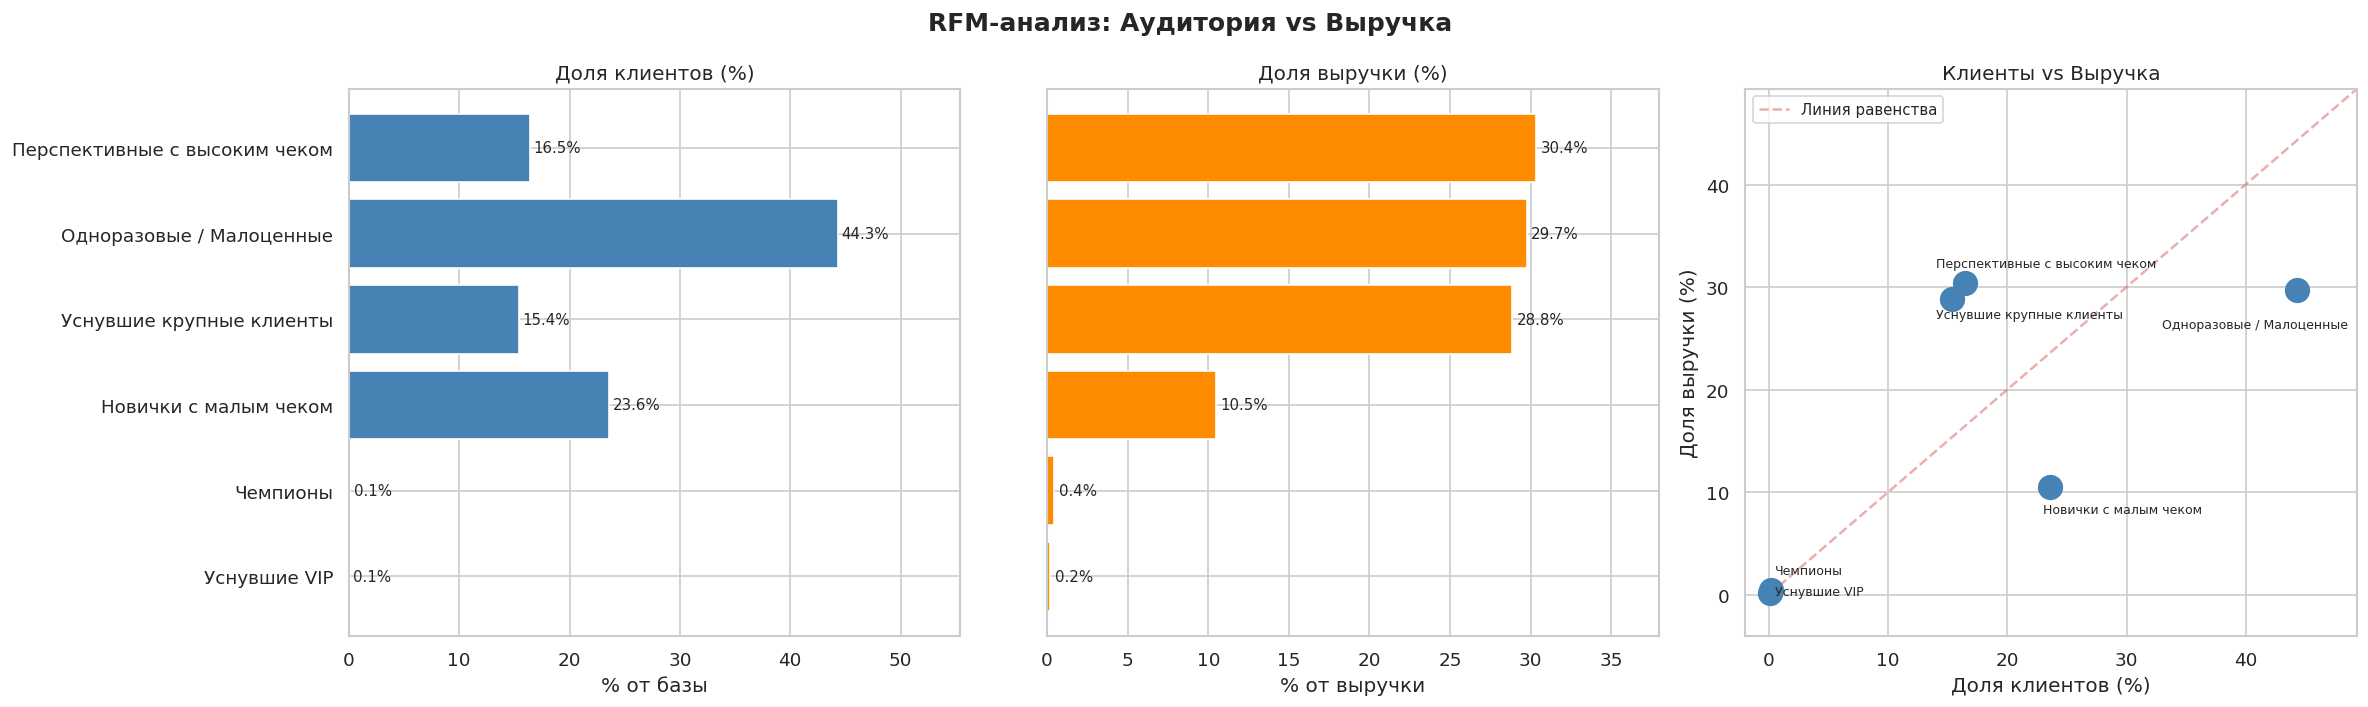

In [ ]:
seg_plot = seg.sort_values('share_revenue_%', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('RFM-анализ: Аудитория vs Выручка', fontsize=15, fontweight='bold')

# График 1: доля клиентов
axes[0].barh(seg_plot['segment'], seg_plot['share_customers_%'], color='steelblue')
axes[0].set_title('Доля клиентов (%)')
axes[0].set_xlabel('% от базы')
for bar, val in zip(axes[0].patches, seg_plot['share_customers_%']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_xlim(0, seg_plot['share_customers_%'].max() * 1.25)

# График 2: доля выручки
axes[1].barh(seg_plot['segment'], seg_plot['share_revenue_%'], color='darkorange')
axes[1].set_title('Доля выручки (%)')
axes[1].set_xlabel('% от выручки')
axes[1].set_yticklabels([])
for bar, val in zip(axes[1].patches, seg_plot['share_revenue_%']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_xlim(0, seg_plot['share_revenue_%'].max() * 1.25)

# График 3: клиенты vs выручка
axes[2].scatter(seg_plot['share_customers_%'], seg_plot['share_revenue_%'],
                s=200, color='steelblue', zorder=3)

# Позиции меток обновлены под новые сегменты
label_positions = {
    'Перспективные с высоким чеком': (14, 32),
    'Уснувшие крупные клиенты':      (14, 27),
    'Одноразовые / Малоценные':      (33, 26),
    'Новички с малым чеком':         (23, 8),
    'Чемпионы':                      (0.5, 2),
    'Уснувшие VIP':                  (0.5, 0),
}

for _, row in seg_plot.iterrows():
    x, y = label_positions.get(row['segment'], (row['share_customers_%'], row['share_revenue_%']))
    axes[2].text(x, y, row['segment'], fontsize=7.5, ha='left')

max_val = max(seg_plot['share_customers_%'].max(), seg_plot['share_revenue_%'].max()) + 5
axes[2].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Линия равенства')
axes[2].set_xlabel('Доля клиентов (%)')
axes[2].set_ylabel('Доля выручки (%)')
axes[2].set_title('Клиенты vs Выручка')
axes[2].set_xlim(-2, max_val)
axes[2].set_ylim(-4, max_val)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Проверка гипотезы H4
top_segments = seg[seg['segment'].isin([
    'Перспективные с высоким чеком',
    'Уснувшие крупные клиенты'
])]

top_customers_pct = top_segments['share_customers_%'].sum()
top_revenue_pct   = top_segments['share_revenue_%'].sum()

ratio = top_revenue_pct / top_customers_pct

/tmp/ipykernel_26014/3347874326.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_revenue, cum_customers)


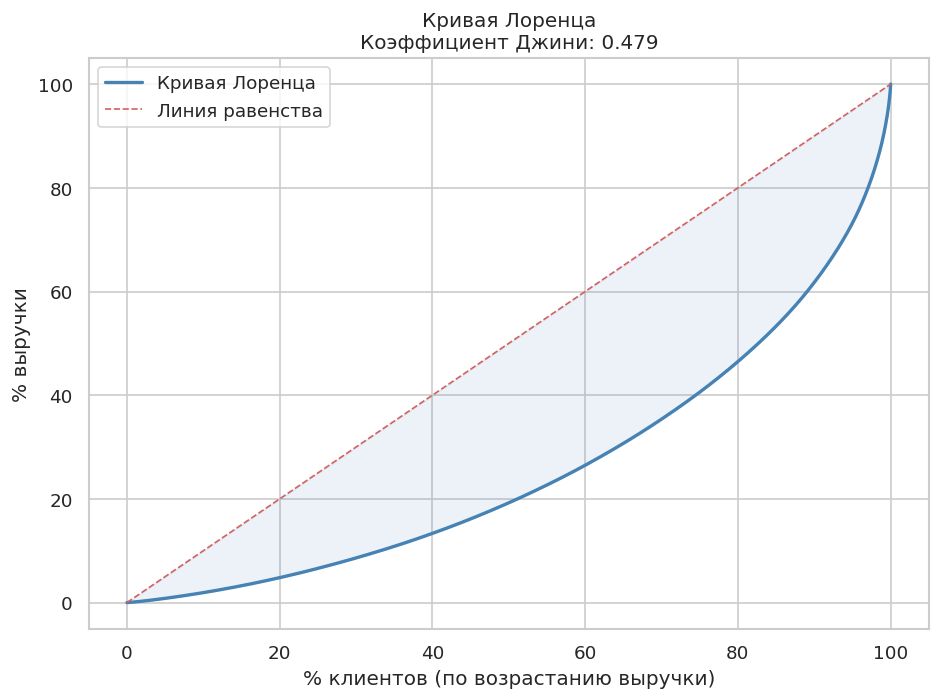


Топ-20% клиентов по выручке генерируют 53.5% совокупной выручки
Коэффициент Джини: 0.479 (0 = равенство, 1 = максимальное неравенство)

Сегменты с высоким чеком (Перспективные + Уснувшие крупные):
  Доля клиентов: 31.8%
  Доля выручки:  59.2%
  Коэффициент диспропорции: x1.86

H4 ПОДТВЕРЖДЕНА двумя независимыми методами:
  1. Сегментный анализ: 31.8% клиентов генерируют 59.2% выручки (x1.86)
  2. Кривая Лоренца: топ-20% клиентов генерируют 53.5% выручки, Джини = 0.479

Примечание: Чемпионы (0.13% базы) и Уснувшие VIP (0.07%) выделены в отдельные
сегменты как клиенты с высокой частотой покупок. Несмотря на малую долю выручки,
это наиболее лояльная аудитория – приоритет для программы удержания.



In [ ]:
# Кривая Лоренца
rfm_sorted = rfm.sort_values('monetary').reset_index(drop=True)
cum_customers = np.arange(1, len(rfm_sorted) + 1) / len(rfm_sorted)
cum_revenue   = rfm_sorted['monetary'].cumsum() / rfm_sorted['monetary'].sum()

# Коэффициент Джини
gini = 1 - 2 * np.trapezoid(cum_revenue, cum_customers)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(cum_customers * 100, cum_revenue * 100, color='steelblue', linewidth=2, label='Кривая Лоренца')
ax.plot([0, 100], [0, 100], 'r--', linewidth=1, label='Линия равенства')
ax.fill_between(cum_customers * 100, cum_revenue * 100, cum_customers * 100, alpha=0.1, color='steelblue')
ax.set_xlabel('% клиентов (по возрастанию выручки)')
ax.set_ylabel('% выручки')
ax.set_title(f'Кривая Лоренца\nКоэффициент Джини: {gini:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

# Топ-20% по выручке
top20_threshold = rfm_sorted['monetary'].quantile(0.80)
top20_revenue   = rfm_sorted[rfm_sorted['monetary'] >= top20_threshold]['monetary'].sum()
top20_share     = top20_revenue / rfm_sorted['monetary'].sum() * 100
print(f"\nТоп-20% клиентов по выручке генерируют {top20_share:.1f}% совокупной выручки")
print(f"Коэффициент Джини: {gini:.3f} (0 = равенство, 1 = максимальное неравенство)")

print(f"""
Сегменты с высоким чеком (Перспективные + Уснувшие крупные):
  Доля клиентов: {top_customers_pct:.1f}%
  Доля выручки:  {top_revenue_pct:.1f}%
  Коэффициент диспропорции: x{ratio:.2f}

H4 ПОДТВЕРЖДЕНА двумя независимыми методами:
  1. Сегментный анализ: {top_customers_pct:.1f}% клиентов генерируют {top_revenue_pct:.1f}% выручки (x{ratio:.2f})
  2. Кривая Лоренца: топ-20% клиентов генерируют {top20_share:.1f}% выручки, Джини = {gini:.3f}

Примечание: Чемпионы (0.13% базы) и Уснувшие VIP (0.07%) выделены в отдельные
сегменты как клиенты с высокой частотой покупок. Несмотря на малую долю выручки,
это наиболее лояльная аудитория – приоритет для программы удержания.
""")

In [ ]:
# Сводная таблица приоритетов
actions = {
    'Чемпионы':                        ('Удержание',    'Программа лояльности, ранний доступ к акциям'),
    'Перспективные с высоким чеком':   ('Конвертация',  'Welcome-цепочка, оффер на вторую покупку в течение 14–30 дней'),
    'Уснувшие VIP':                    ('Реактивация',  'Персональное предложение, высокий пороговый бонус'),
    'Уснувшие крупные клиенты':        ('Реактивация',  'Таргетированная рассылка по категории первой покупки'),
    'Новички с малым чеком':           ('Апсейл',       'Кросс-селл смежных категорий, порог бесплатной доставки'),
    'Одноразовые / Малоценные':        ('Исключить',    'Не тратить бюджет платных каналов на реактивацию'),
}

summary = seg[['segment', 'n_customers', 'share_customers_%', 'share_revenue_%', 'avg_monetary', 'avg_recency']].copy()
summary['приоритет']      = summary['segment'].map(lambda s: actions[s][0])
summary['действие']       = summary['segment'].map(lambda s: actions[s][1])
summary['avg_monetary']   = summary['avg_monetary'].round(1)
summary['avg_recency']    = summary['avg_recency'].round(0).astype(int)
summary = summary.sort_values('share_revenue_%', ascending=False).reset_index(drop=True)

summary.columns = ['Сегмент', 'Клиентов', 'Доля базы %', 'Доля выручки %',
                   'Средний чек', 'Давность (дни)', 'Приоритет', 'Действие']

print(summary.to_string(index=False))

                      Сегмент  Клиентов  Доля базы %  Доля выручки %  Средний чек  Давность (дни)   Приоритет                                                      Действие
Перспективные с высоким чеком     15326        16.46           30.35        304.5              91 Конвертация Welcome-цепочка, оффер на вторую покупку в течение 14–30 дней
     Одноразовые / Малоценные     41282        44.34           29.74        110.8             315   Исключить              Не тратить бюджет платных каналов на реактивацию
     Уснувшие крупные клиенты     14320        15.38           28.82        309.5             391 Реактивация          Таргетированная рассылка по категории первой покупки
        Новички с малым чеком     21986        23.61           10.46         73.1              90      Апсейл       Кросс-селл смежных категорий, порог бесплатной доставки
                     Чемпионы       121         0.13            0.44        557.4              90   Удержание                  Программа лоя

## Результаты RFM-сегментации

**H4 подтверждена двумя независимыми методами.**

**Сегментный анализ:** 31.8% клиентской базы генерируют 59.2% совокупной выручки.
Коэффициент диспропорции – x1.86.

**Кривая Лоренца:** топ-20% клиентов генерируют 53.5% выручки.
Коэффициент Джини – 0.479. Высокая концентрация выручки подтверждается
независимо от выбора сегментов.

## 6. Стратегическое резюме

Olist находится в фазе роста за счёт агрессивного привлечения новых клиентов.
Органическое удержание отсутствует – повторные покупки совершают менее 3% базы.
Устойчивость модели напрямую зависит от стоимости привлечения: при росте CAC
экономика платформы начнёт сходиться в минус.

Наиболее ценный актив на текущем этапе – сегмент «Перспективные с высоким чеком»
(16.5% базы, 30.4% выручки). Это недавние клиенты с высоким чеком, ещё не ушедшие в отток. Без активного удержания большинство из них перейдёт в сегмент «Уснувших» в течение 3-6 месяцев.

**Приоритеты:**

1. **Welcome-цепочка для «Перспективных»** – оффер на вторую покупку в течение 14–30 дней.
2. **Реактивация «Уснувших крупных клиентов»** – таргетированные рассылки по категории первой покупки.
3. **Удержание «Чемпионов» и «Уснувших VIP»** – программа лояльности и персональные предложения. Малочисленны, но формируют поведенческий паттерн повторных покупок.
4. **Исключить «Одноразовых / Малоценных»** из платных каналов коммуникации – стоимость реактивации заведомо превышает потенциальный LTV.